In [3]:
import pandas as pd

df = pd.read_csv(r"flight_delay.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(36796, 119)
['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Originally_Scheduled_Code_Share_Airline', 'DOT_ID_Originally_Scheduled_Code_Share_Airline', 'IATA_Code_Originally_Scheduled_Code_Share_Airline', 'Flight_Num_Originally_Scheduled_Code_Share_Airline', 'Operating_Airline ', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'Origin', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'Dest', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'Wheels

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate
0,2022,1,1,6,4,06-01-2022,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,2022,1,1,6,4,06-01-2022,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,2022,1,1,6,4,06-01-2022,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
3,2022,1,1,6,4,06-01-2022,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,2022,1,1,6,4,06-01-2022,DL,DL,19790,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


In [4]:
columns = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "Marketing_Airline_Network",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup",
    "ArrDel15"
]

df = df[columns]

print(df.shape)
df.head()

(36796, 14)


,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Origin,Dest,CRSDepTime,CRSArrTime,CRSElapsedTime,Distance,DistanceGroup,ArrDel15
0,2022,1,1,6,4,DL,FLL,LGA,1126.0,1419.0,173.0,1076.0,5.0,NaN
1,2022,1,1,6,4,DL,ATL,FLL,1631.0,1821.0,110.0,581.0,3.0,0.0
2,2022,1,1,6,4,DL,FLL,ATL,1931.0,2127.0,116.0,581.0,3.0,0.0
3,2022,1,1,6,4,DL,FLL,RDU,1024.0,1227.0,123.0,680.0,3.0,0.0
4,2022,1,1,6,4,DL,ATL,JAN,1117.0,1142.0,85.0,341.0,2.0,0.0


In [5]:
print(df.isnull().sum())

Year                            0
Quarter                         0
Month                           0
DayofMonth                      0
DayOfWeek                       0
Marketing_Airline_Network       0
Origin                          0
Dest                            1
CRSDepTime                      1
CRSArrTime                      1
CRSElapsedTime                  1
Distance                        1
DistanceGroup                   1
ArrDel15                     1781
dtype: int64


In [6]:
df = df.dropna()

print(df.shape)

(35015, 14)


In [7]:
print(df["ArrDel15"].value_counts())

ArrDel15
0.0    29048
1.0     5967
Name: count, dtype: int64


In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 35015 entries, 1 to 36794
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       35015 non-null  int64  
 1   Quarter                    35015 non-null  int64  
 2   Month                      35015 non-null  int64  
 3   DayofMonth                 35015 non-null  int64  
 4   DayOfWeek                  35015 non-null  int64  
 5   Marketing_Airline_Network  35015 non-null  object 
 6   Origin                     35015 non-null  object 
 7   Dest                       35015 non-null  object 
 8   CRSDepTime                 35015 non-null  float64
 9   CRSArrTime                 35015 non-null  float64
 10  CRSElapsedTime             35015 non-null  float64
 11  Distance                   35015 non-null  float64
 12  DistanceGroup              35015 non-null  float64
 13  ArrDel15                   35015 non-null  float64


In [9]:
X = df.drop("ArrDel15", axis=1)
y = df["ArrDel15"]

print(X.shape)
print(y.shape)

(35015, 13)
(35015,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(28012, 13)
(7003, 13)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_cols = [
    "Marketing_Airline_Network",
    "Origin",
    "Dest"
]

numeric_cols = [
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "DistanceGroup"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.826360131372269

Classification Report:

              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90      5810
         1.0       0.46      0.11      0.18      1193

    accuracy                           0.83      7003
   macro avg       0.65      0.54      0.54      7003
weighted avg       0.78      0.83      0.78      7003



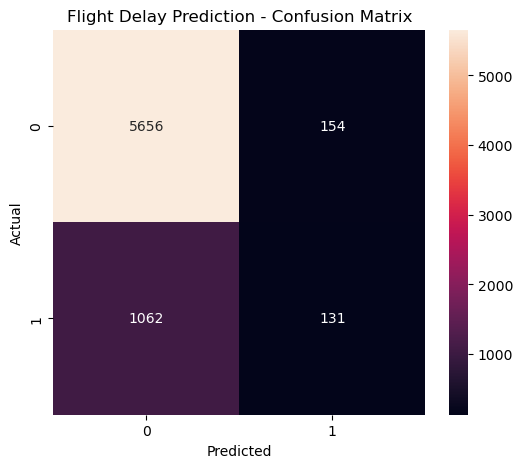

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Flight Delay Prediction - Confusion Matrix")
plt.show()

In [17]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importance = model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance", ascending=False
)

feature_importance.head(15)

,Feature,Importance
3,num__DayofMonth,0.191457
6,num__CRSArrTime,0.116595
5,num__CRSDepTime,0.110948
7,num__CRSElapsedTime,0.100018
4,num__DayOfWeek,0.099507
8,num__Distance,0.060973
9,num__DistanceGroup,0.025546
146,cat__Dest_ATL,0.007203
14,cat__Origin_ATL,0.006430
225,cat__Dest_MSP,0.005597


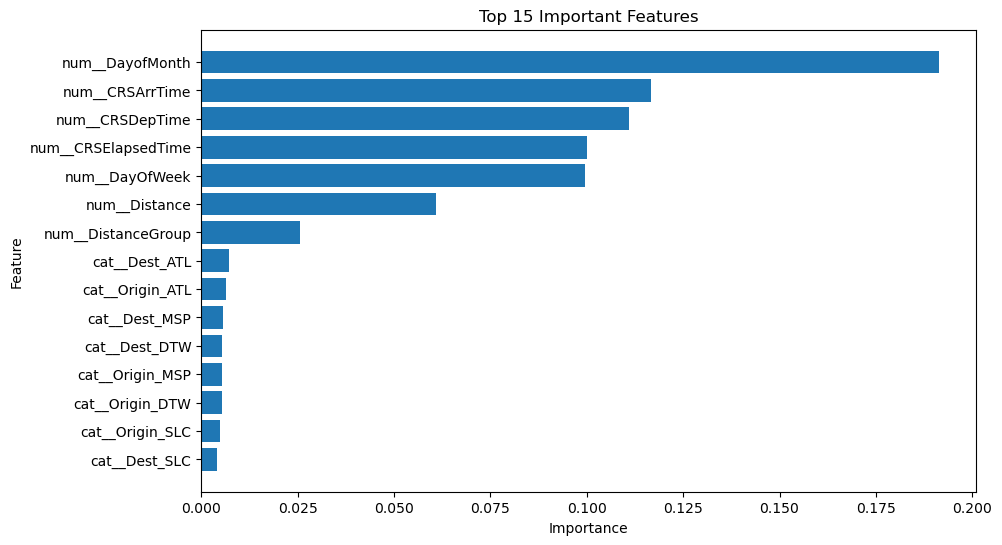

In [18]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [19]:
import joblib

joblib.dump(model, "flight_delay_model.pkl")

print("Model saved successfully!")

Model saved successfully!
